In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
def d_score(df):
  
    df = df[df["score"] == 1].copy() 
    df = df[(df["rt"] >= 300) & (df["rt"] <= 10000)].copy() 

    congruent = df[df["block"] == 3]["rt"] 
    incongruent = df[df["block"] == 6]["rt"] 

    mean_c = congruent.mean() 
    mean_i = incongruent.mean() 

    sd_c = congruent.std(ddof=1) 
    sd_i = incongruent.std(ddof=1) 
    

    sd_pooled = np.sqrt((sd_c**2 + sd_i**2) / 2) 
 
    d_score = (mean_i - mean_c) / sd_pooled if sd_pooled != 0 else 0
   
    return d_score, len(df)

def d_with_penalty_ifn(df1):
    # dscore with penalty for (incorrect + failure + noise)
 
    df1 = df1[(df1["rt"] >= 300) & (df1["rt"] <= 10000)].copy() 
    df1["rt_adj"] = df1["rt"].astype(float)


    mean_c_correct = df1.loc[(df1["block"] == 3) & (df1["score"] == 1), "rt"].mean()
    mean_i_correct = df1.loc[(df1["block"] == 6) & (df1["score"] == 1), "rt"].mean()

    df1.loc[(df1["block"] == 3) & (df1["score"] == 0), "rt_adj"] = mean_c_correct + 600
    df1.loc[(df1["block"] == 6) & (df1["score"] == 0), "rt_adj"] = mean_i_correct + 600

    congruent = df1[df1["block"] == 3]["rt_adj"] 
    incongruent = df1[df1["block"] == 6]["rt_adj"] 

    mean_c = congruent.mean() 
    mean_i = incongruent.mean() 

    sd_c = congruent.std(ddof=1) 
    sd_i = incongruent.std(ddof=1) 

    sd_pooled = np.sqrt((sd_c**2 + sd_i**2) / 2) 

    d_score = (mean_i - mean_c) / sd_pooled if sd_pooled != 0 else 0
    corr = len(df1[((df1["block"] == 3) & (df1["score"] == 1))|((df1["block"] == 6) & (df1["score"] == 1)) ])
    return d_score, corr 

def d_with_penalty_in(df1):
    # dscore with penalty for (incorrect  + noise)

    df1 = df1[df1["response"] != 'w'].copy() 
 
    df1 = df1[(df1["rt"] >= 300) & (df1["rt"] <= 10000)].copy() 
    df1["rt_adj"] = df1["rt"].astype(float)


    mean_c_correct = df1.loc[(df1["block"] == 3) & (df1["score"] == 1), "rt"].mean()
    mean_i_correct = df1.loc[(df1["block"] == 6) & (df1["score"] == 1), "rt"].mean()

    df1.loc[(df1["block"] == 3) & (df1["score"] == 0), "rt_adj"] = mean_c_correct + 600
    df1.loc[(df1["block"] == 6) & (df1["score"] == 0), "rt_adj"] = mean_i_correct + 600

    congruent = df1[df1["block"] == 3]["rt_adj"] 
    incongruent = df1[df1["block"] == 6]["rt_adj"] 

    mean_c = congruent.mean() 
    mean_i = incongruent.mean() 

    sd_c = congruent.std(ddof=1) 
    sd_i = incongruent.std(ddof=1) 

    sd_pooled = np.sqrt((sd_c**2 + sd_i**2) / 2) 

    d_score = (mean_i - mean_c) / sd_pooled if sd_pooled != 0 else 0
    # corr = len(df1[((df1["block"] == 3) & (df1["score"] == 1))|((df1["block"] == 6) & (df1["score"] == 1)) ])
    return d_score

def d_with_penalty_i(df1):
    # dscore with penalty for (incorrect only)
    df1 = df1[df1["response"].isin(['a','d'])].copy() 
    df1 = df1[(df1["rt"] >= 300) & (df1["rt"] <= 10000)].copy() 
    df1["rt_adj"] = df1["rt"].astype(float)


    mean_c_correct = df1.loc[(df1["block"] == 3) & (df1["score"] == 1), "rt"].mean()
    mean_i_correct = df1.loc[(df1["block"] == 6) & (df1["score"] == 1), "rt"].mean()
    

    df1.loc[(df1["block"] == 3) & (df1["score"] == 0), "rt_adj"] = mean_c_correct + 600
    df1.loc[(df1["block"] == 6) & (df1["score"] == 0), "rt_adj"] = mean_i_correct + 600

    congruent = df1[df1["block"] == 3]["rt_adj"] 
    incongruent = df1[df1["block"] == 6]["rt_adj"] 

    mean_c = congruent.mean() 
    mean_i = incongruent.mean() 

    sd_c = congruent.std(ddof=1) 
    sd_i = incongruent.std(ddof=1) 

    sd_pooled = np.sqrt((sd_c**2 + sd_i**2) / 2) 

    d_score = (mean_i - mean_c) / sd_pooled if sd_pooled != 0 else 0
    return d_score
 
def s_count_if_there(df1):
    return (df1["response"].astype(str).str.lower() == 's').sum()

def w_count_if_there(df1):
    return (df1["response"].astype(str).str.lower() == 'w').sum()

def incorrect_retrievals(df1):
    return ((df1["score"] == 0) & (df1["response"].isin(['d','a']))).sum()








In [3]:
# human
def d_score_h(df):
  
    df = df[df["score"] == 1].copy() 


    congruent = df[df["block"] == 3]["rt"] 
    incongruent = df[df["block"] == 5]["rt"] 

    mean_c = congruent.mean() 
    mean_i = incongruent.mean() 

    sd_c = congruent.std(ddof=1) 
    sd_i = incongruent.std(ddof=1) 
    

    sd_pooled = np.sqrt((sd_c**2 + sd_i**2) / 2) 
 
    d_score = (mean_i - mean_c) / sd_pooled if sd_pooled != 0 else 0
   
    return d_score, len(df)

def d_with_penalty_ifn_h(df1):
    # dscore with penalty for (incorrect + failure + noise)
 
    df1["rt_adj"] = df1["rt"].astype(float)


    mean_c_correct = df1.loc[(df1["block"] == 3) & (df1["score"] == 1), "rt"].mean()
    mean_i_correct = df1.loc[(df1["block"] == 5) & (df1["score"] == 1), "rt"].mean()

    df1.loc[(df1["block"] == 3) & (df1["score"] == 0), "rt_adj"] = mean_c_correct + 600
    df1.loc[(df1["block"] == 5) & (df1["score"] == 0), "rt_adj"] = mean_i_correct + 600

    congruent = df1[df1["block"] == 3]["rt_adj"] 
    incongruent = df1[df1["block"] == 5]["rt_adj"] 

    mean_c = congruent.mean() 
    mean_i = incongruent.mean() 

    sd_c = congruent.std(ddof=1) 
    sd_i = incongruent.std(ddof=1) 

    sd_pooled = np.sqrt((sd_c**2 + sd_i**2) / 2) 

    d_score = (mean_i - mean_c) / sd_pooled if sd_pooled != 0 else 0
    corr = len(df1[((df1["block"] == 3) & (df1["score"] == 1))|((df1["block"] == 5) & (df1["score"] == 1)) ])
    return d_score, corr 










In [4]:
all_scores = [] 
df_data = pd.read_csv("Human.csv")
df_data = df_data[(df_data["rt"] > 200) & (df_data["rt"] < 10000)]
for lid, df in df_data.groupby("name"):
    d_score_without_penalty, correct_recs = d_score_h(df) 
    d_score_with_penalty,correct_test_recs = d_with_penalty_ifn_h(df) 
    accuracy = (correct_recs/70) *100
    test_accuracy = (correct_test_recs/40) * 100
    inc = incorrect_retrievals(df)
    inc_perc = (inc/70)*100
    # if int(accuracy)>30 and int(test_accuracy)>30:
    # print(csv_path.name)
    all_scores.append({ 
        "relative_path": "Human",
        "file_name":  lid, 
        "d_score": d_score_without_penalty,
        "d_score_with_penalty":d_score_with_penalty,
        "d_score_with_penalty_without_ret_fail":0,
        "d_score_with_penalty_only_c_ic":0,
        "s_count":0,
        "w_count":0,
        "correct_recs": correct_recs,
        "accuracy":accuracy,
        "correct_test_recs":correct_test_recs,
        "test_accuracy":test_accuracy,
        "incorrect_recs": inc,
        "noise_perc":0,
        "failure_perc":0,
        "inc_perc":inc_perc

    }) 
print(len(all_scores))

104


In [5]:

df_data = pd.read_csv("DM.csv")

for lid, df in df_data.groupby("filename"):
    d_score_without_penalty, correct_recs = d_score(df) 
    d_score_with_penalty,correct_test_recs = d_with_penalty_ifn(df) 
    d_score_with_penalty_without_ret_fail = d_with_penalty_in(df)
    d_score_with_penalty_only_c_ic = d_with_penalty_i(df)
    accuracy = (correct_recs/70) *100
    test_accuracy = (correct_test_recs/40) * 100
    inc = incorrect_retrievals(df)
    inc_perc = (inc/70)*100
    s_count = s_count_if_there(df)
    w_count = w_count_if_there(df)
    inc = incorrect_retrievals(df)
    s_count_perc = (s_count/70)*100
    w_count_perc = (w_count/70)*100
    inc_perc = (inc/70)*100 
 
 
    # if int(accuracy)>30 and int(test_accuracy)>30:
    # print(csv_path.name)
    all_scores.append({ 
        "relative_path": "DM",
        "file_name":  lid, 
        "d_score": d_score_without_penalty,
        "d_score_with_penalty":d_score_with_penalty,
        "d_score_with_penalty_without_ret_fail":d_score_with_penalty_without_ret_fail,
        "d_score_with_penalty_only_c_ic":d_score_with_penalty_only_c_ic,
        "s_count":s_count,
        "w_count":w_count,
        "correct_recs": correct_recs,
        "accuracy":accuracy,
        "correct_test_recs":correct_test_recs,
        "test_accuracy":test_accuracy,
        "incorrect_recs": inc,
        "noise_perc":s_count_perc,
        "failure_perc":w_count_perc,
        "inc_perc":inc_perc

    }) 
print(len(all_scores))

204


In [6]:
input_directory = "../Outputs" 

from pathlib import Path 
invalid_records=[]


for csv_path in Path(input_directory).rglob("*.csv"):
    try: 

        df = pd.read_csv(csv_path)
        if (not (df["rt"] <0 ).any()):
            d_score_without_penalty, correct_recs = d_score(df) 
            d_score_with_penalty,correct_test_recs = d_with_penalty_ifn(df) 
            d_score_with_penalty_without_ret_fail = d_with_penalty_in(df)
            d_score_with_penalty_only_c_ic = d_with_penalty_i(df)
            accuracy = (correct_recs/70) *100
            test_accuracy = (correct_test_recs/40) * 100
            s_count = s_count_if_there(df)
            w_count = w_count_if_there(df)
            inc = incorrect_retrievals(df)
            s_count_perc = (s_count/70)*100
            w_count_perc = (w_count/70)*100
            inc_perc = (inc/70)*100
            # if int(accuracy)>30 and int(test_accuracy)>30:
            # print(csv_path.name)
            all_scores.append({ 
                "relative_path": csv_path.parent.relative_to(input_directory).as_posix(),
                "file_name":  csv_path.name, 
                "d_score": d_score_without_penalty,
                "d_score_with_penalty":d_score_with_penalty,
                "d_score_with_penalty_without_ret_fail":d_score_with_penalty_without_ret_fail,
                "d_score_with_penalty_only_c_ic":d_score_with_penalty_only_c_ic,
                "s_count":s_count,
                "w_count":w_count,
                "correct_recs": correct_recs,
                "accuracy":accuracy,
                "correct_test_recs":correct_test_recs,
                "test_accuracy":test_accuracy,
                "incorrect_recs": inc,
                "noise_perc":s_count_perc,
                "failure_perc":w_count_perc,
                "inc_perc":inc_perc

            }) 
        else:
            invalid_records.append(csv_path.name)

    except Exception as e: 
        print(f"Error processing { csv_path.name}: {e}") 
df1 = pd.DataFrame(all_scores) 

 

In [7]:
columns = df1.columns[2:]
grouped = df1.groupby("relative_path")[columns].agg(["mean","sem"])
grouped.columns = [f"{column}_{stat}" for column,stat in grouped.columns] 
grouped["count"] = df1.groupby("relative_path").size()
grouped = grouped.reset_index()
grouped

,relative_path,d_score_mean,d_score_sem,d_score_with_penalty_mean,d_score_with_penalty_sem,d_score_with_penalty_without_ret_fail_mean,d_score_with_penalty_without_ret_fail_sem,d_score_with_penalty_only_c_ic_mean,d_score_with_penalty_only_c_ic_sem,s_count_mean,...,test_accuracy_sem,incorrect_recs_mean,incorrect_recs_sem,noise_perc_mean,noise_perc_sem,failure_perc_mean,failure_perc_sem,inc_perc_mean,inc_perc_sem,count
0,Baseline,-0.009814,0.020871,-0.000842,0.007209,0.002895,0.021092,-0.020540,0.025820,3.250000,...,1.224773,0.580000,0.124868,4.642857,0.516627,32.485714,1.176037,0.828571,0.178382,100
1,CN chunk/all,-0.019421,0.051302,-0.002253,0.008228,-0.004198,0.008142,-0.039969,0.050010,36.540000,...,1.228088,0.240000,0.063755,52.200000,1.492014,15.542857,0.724823,0.342857,0.091078,100
2,CN chunk/black,-0.040125,0.060134,-0.010668,0.010804,-0.010848,0.010574,-0.066038,0.062268,35.613861,...,1.224515,0.297030,0.076488,50.876945,1.293778,18.118812,0.858304,0.424328,0.109269,101
3,CN chunk/white,-0.071795,0.056679,-0.009953,0.009462,-0.009540,0.009126,-0.034127,0.058493,35.396040,...,1.253756,0.386139,0.080801,50.565771,1.384187,17.270156,0.974332,0.551627,0.115430,101
4,CN text/all,0.005538,0.017290,0.007266,0.007410,0.009000,0.007859,0.016205,0.020961,10.320000,...,0.875664,0.370000,0.091734,14.742857,0.853499,3.971429,0.348499,0.528571,0.131049,100
5,CN text/black,-0.000423,0.018152,0.006021,0.006036,0.007714,0.006731,0.015308,0.021332,11.530000,...,0.981711,0.280000,0.068283,16.471429,0.911109,3.657143,0.329489,0.400000,0.097548,100
6,CN text/white,0.015940,0.014371,0.023375,0.008368,0.025354,0.010158,0.059549,0.020373,10.760000,...,0.955896,0.520000,0.105868,15.371429,0.960811,5.000000,0.400731,0.742857,0.151240,100
7,DM,0.002312,0.007658,0.002312,0.007658,0.002312,0.007658,0.002312,0.007658,0.000000,...,0.068165,6.000000,0.000000,0.000000,0.000000,1.428571,0.000000,8.571429,0.000000,100
8,Human,-0.028498,0.067557,0.007088,0.069492,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.035814,1.096154,0.163695,0.000000,0.000000,0.000000,0.000000,1.565934,0.233850,104
9,LLM chunk/All,-0.012597,0.047202,-0.013132,0.007943,-0.013821,0.008188,-0.046260,0.048700,40.020000,...,1.297667,0.380000,0.082609,57.171429,1.431452,8.014286,0.534096,0.542857,0.118013,100


In [8]:
order= ['Human','DM','Baseline', 'Chunk All', 'Chunk Black','Chunk White','Corpus All', 'Corpus Black', 'Corpus White']
display_map_labels= {'Human':'Human','DM':'DM','Baseline':'Baseline', 'Chunk All':'Chunk\nAll', 'Chunk Black':'Chunk\nBlack','Chunk White':'Chunk\nWhite',
                                    'Corpus All':'Corpus\nAll', 'Corpus Black':'Corpus\nBlack', 'Corpus White':'Corpus\nWhite'}

display_map ={
    "Human": ("Human","Human"),
    "DM" : ("DM","DM"),
    "Baseline" : ("Baseline","Baseline"),
    "CN chunk/all": ("Chunk All", "ConceptNet"),
    "CN chunk/black": ("Chunk Black", "ConceptNet"),
    "CN chunk/white": ("Chunk White", "ConceptNet"),
    "CN text/all": ("Corpus All","ConceptNet"),
    "CN text/black": ("Corpus Black","ConceptNet"),
    "CN text/white": ("Corpus White","ConceptNet"),
    "LLM chunk/All": ("Chunk All","LLM"),
    "LLM chunk/Black": ("Chunk Black","LLM"),
    "LLM chunk/White": ("Chunk White","LLM"),
    "LLM text/All": ("Corpus All","LLM"),
    "LLM text/Black": ("Corpus Black","LLM"),
    "LLM text/White": ("Corpus White","LLM"),
}
color_map = {
    "Human":"black",
	"DM":"yellow",
    "Baseline" :"gray",
    "ConceptNet":"blue",
    "LLM":"orange"
}


In [9]:
grouped[["Label", "Source"]] = grouped["relative_path"].map(display_map).apply(pd.Series)
grouped_filtered = grouped.dropna().copy()
# Ensure fixed label order
grouped_filtered["Label"] = pd.Categorical(grouped_filtered["Label"], categories=order, ordered=True)
grouped_filtered = grouped_filtered.sort_values(["Label", "Source"])



In [ ]:

grouped_filtered[["Method","Corpus"]] = grouped_filtered["Label"].str.split(" ",n=1, expand=True)


In [13]:

human_df = grouped_filtered[grouped_filtered["Source"] == "Human"]
baseline_df = grouped_filtered[grouped_filtered["Source"] == "Baseline"]
dm_df = grouped_filtered[grouped_filtered["Source"] == "DM"]
cn_df = grouped_filtered[grouped_filtered["Source"] == "ConceptNet"].sort_values("Label")
llm_df = grouped_filtered[grouped_filtered["Source"] == "LLM"].sort_values("Label")

In [14]:
grouped_filtered_without_baseline = grouped_filtered[(grouped_filtered['Label'] != 'Human') & (grouped_filtered['Label'] != 'Baseline') & (grouped_filtered['Label'] != 'DM')]
grouped_filtered_without_baseline = grouped_filtered_without_baseline.drop(columns=["Label"])
grouped_filtered_without_baseline.head()

,relative_path,d_score_mean,d_score_sem,d_score_with_penalty_mean,d_score_with_penalty_sem,d_score_with_penalty_without_ret_fail_mean,d_score_with_penalty_without_ret_fail_sem,d_score_with_penalty_only_c_ic_mean,d_score_with_penalty_only_c_ic_sem,s_count_mean,...,noise_perc_mean,noise_perc_sem,failure_perc_mean,failure_perc_sem,inc_perc_mean,inc_perc_sem,count,Source,Method,Corpus
1,CN chunk/all,-0.019421,0.051302,-0.002253,0.008228,-0.004198,0.008142,-0.039969,0.050010,36.540000,...,52.200000,1.492014,15.542857,0.724823,0.342857,0.091078,100,ConceptNet,Chunk,All
9,LLM chunk/All,-0.012597,0.047202,-0.013132,0.007943,-0.013821,0.008188,-0.046260,0.048700,40.020000,...,57.171429,1.431452,8.014286,0.534096,0.542857,0.118013,100,LLM,Chunk,All
2,CN chunk/black,-0.040125,0.060134,-0.010668,0.010804,-0.010848,0.010574,-0.066038,0.062268,35.613861,...,50.876945,1.293778,18.118812,0.858304,0.424328,0.109269,101,ConceptNet,Chunk,Black
10,LLM chunk/Black,-0.084082,0.053668,-0.007711,0.009556,-0.008401,0.009471,-0.055777,0.053052,39.640000,...,56.628571,1.560637,9.657143,0.690997,0.514286,0.119298,100,LLM,Chunk,Black
3,CN chunk/white,-0.071795,0.056679,-0.009953,0.009462,-0.009540,0.009126,-0.034127,0.058493,35.396040,...,50.565771,1.384187,17.270156,0.974332,0.551627,0.115430,101,ConceptNet,Chunk,White


[<matplotlib.lines.Line2D object at 0x000001AC0109DD60>, <matplotlib.lines.Line2D object at 0x000001AC010B5910>, <matplotlib.lines.Line2D object at 0x000001AC010B4D70>, <matplotlib.lines.Line2D object at 0x000001AC010B4320>, <matplotlib.lines.Line2D object at 0x000001AC010B5F10>, <matplotlib.lines.Line2D object at 0x000001AC010B6180>, <matplotlib.lines.Line2D object at 0x000001AC010B6390>, <matplotlib.lines.Line2D object at 0x000001AC010B65D0>, <matplotlib.lines.Line2D object at 0x000001AC010B6840>, <matplotlib.lines.Line2D object at 0x000001AC010B6A80>, <matplotlib.collections.PathCollection object at 0x000001ABFFD65400>, <matplotlib.collections.PathCollection object at 0x000001AC03160560>, <matplotlib.collections.PathCollection object at 0x000001AC03160DD0>]
['Corpus', 'All', 'Black', 'White', 'Method', 'Chunk', 'Corpus', 'Source', 'ConceptNet', 'LLM', 'Baseline', 'DM', 'Human']


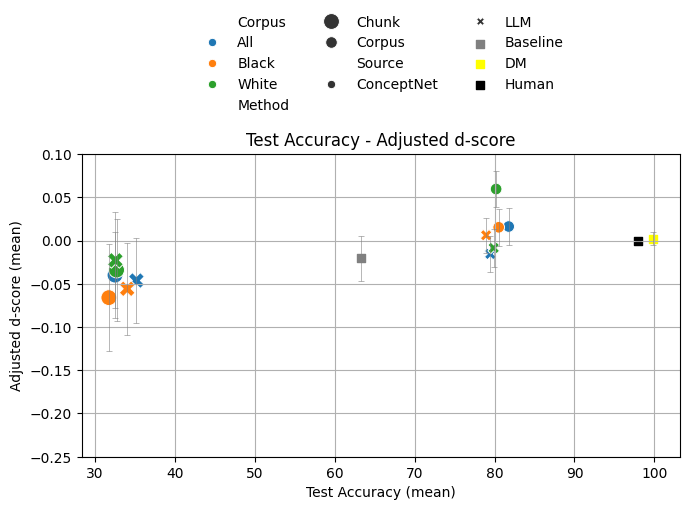

In [15]:
import seaborn as sns

plt.figure(figsize=(7,6))
hl = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["d_score_with_penalty_only_c_ic_mean"][0]
vl = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["test_accuracy_mean"][0]
hl_sem = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["d_score_with_penalty_only_c_ic_sem"][0]

h2 = grouped_filtered[grouped_filtered['Label'] == 'DM']["d_score_with_penalty_only_c_ic_mean"][7]
v2 = grouped_filtered[grouped_filtered['Label'] == 'DM']["test_accuracy_mean"][7]
h2_sem = grouped_filtered[grouped_filtered['Label'] == 'DM']["d_score_with_penalty_only_c_ic_sem"][7]

h3 = grouped_filtered[grouped_filtered['Label'] == 'Human']["d_score_with_penalty_only_c_ic_mean"][8]
v3 = grouped_filtered[grouped_filtered['Label'] == 'Human']["test_accuracy_mean"][8]
h3_sem = grouped_filtered[grouped_filtered['Label'] == 'Human']["d_score_with_penalty_only_c_ic_sem"][8]

ax = sns.scatterplot(
    data=grouped_filtered_without_baseline,
    hue="Corpus",          
    x="test_accuracy_mean",
    y="d_score_with_penalty_only_c_ic_mean",
    style="Source",
    legend ="full",
    size= "Method",
    sizes=(70,130)
)
for _, row in grouped_filtered_without_baseline.iterrows():
    ax.errorbar(
        row["test_accuracy_mean"],
        row["d_score_with_penalty_only_c_ic_mean"],
        yerr=row["d_score_with_penalty_only_c_ic_sem"],   
        fmt='none',
        capsize=2,
        capthick=0.5,
        elinewidth=0.5,
        ecolor='gray',
        alpha=0.8

    )

ax.grid()
ax.scatter(vl,hl,color="gray", marker="s", label ="Baseline")
ax.errorbar(vl,hl,yerr=hl_sem,fmt='none',capsize=2,capthick=0.5,elinewidth=0.5,ecolor='gray',alpha=0.8)
ax.scatter(v2,h2,color="yellow", marker="s", label ="DM")
ax.errorbar(v2,h2,yerr=h2_sem,fmt='none',capsize=2,capthick=0.5,elinewidth=0.5,ecolor='gray',alpha=0.8)
ax.scatter(v3,h3,color="black", marker="s", label ="Human")
ax.errorbar(v3,h3,yerr=h3_sem,fmt='none',capsize=2,capthick=0.5,elinewidth=0.5,ecolor='gray',alpha=0.8)
handles, labelz = ax.get_legend_handles_labels()
print(handles)
print(labelz)
ax.legend(handles=handles, labels = labelz, bbox_to_anchor=(0.5,1.5),loc="upper center",frameon=False,ncol=3)
ax.set_ylim(-0.25,0.10)
ax.set_xlabel("Test Accuracy (mean)")
ax.set_ylabel("Adjusted d-score (mean)")
ax.set_title("Test Accuracy - Adjusted d-score")

plt.tight_layout()
plt.show()

In [16]:
status_order_map = {"accuracy_mean":"Correct","inc_perc_mean": "Incorrect", 
                    "failure_perc_mean":"Failed", "noise_perc_mean":"Noise"}
status_cols = list(status_order_map.keys())
status_labels = list(status_order_map.values())

other_cols = ["Source","Label","relative_path"]
print(other_cols)
other_cols.extend(status_cols)
print(status_cols)
print(other_cols)
plotting_df = grouped_filtered[other_cols].copy()


['Source', 'Label', 'relative_path']
['accuracy_mean', 'inc_perc_mean', 'failure_perc_mean', 'noise_perc_mean']
['Source', 'Label', 'relative_path', 'accuracy_mean', 'inc_perc_mean', 'failure_perc_mean', 'noise_perc_mean']


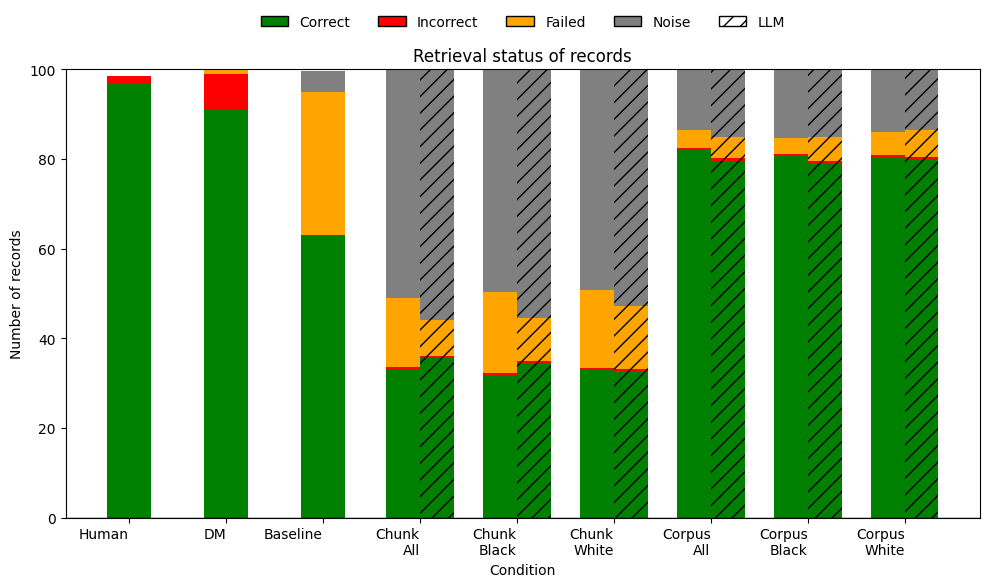

In [17]:

status_colors = {
    "accuracy_mean": "green",
    "inc_perc_mean": "red",
    "failure_perc_mean": "orange",
    "noise_perc_mean": "gray",
}
pbdf = plotting_df[plotting_df["Label"]=="Baseline"]
phdf = plotting_df[plotting_df["Label"]=="Human"]
pdmdf = plotting_df[plotting_df["Label"]=="DM"]
pcndp = plotting_df[plotting_df["Source"] == "ConceptNet"]
pllmdf = plotting_df[plotting_df["Source"] == "LLM"]
x = np.arange(len(order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

baseline_bottom = 0

for col in status_cols:
    ax.bar(
        x[2],
        pbdf[col].values[0],
        width=0.45,
        bottom=baseline_bottom,
        color=status_colors[col],
        label=status_order_map[col],
        # edgecolor="black"
    )

    baseline_bottom += pbdf[col].astype(int).values[0]

dm_bottom = np.zeros(len(pdmdf))
for col in status_cols:
    ax.bar(
        x[1],
        pdmdf[col].values[0],
        width=0.45,
        bottom=dm_bottom,
        color=status_colors[col],
        label=status_order_map[col],
        # edgecolor="black"
    )

    dm_bottom += pdmdf[col].astype(int).values[0]

hm_bottom = np.zeros(len(phdf))
for col in status_cols:
    ax.bar(
        x[0],
        phdf[col].values[0],
        width=0.45,
        bottom=hm_bottom,
        color=status_colors[col],
        label=status_order_map[col],
        # edgecolor="black"
    )

    hm_bottom += phdf[col].astype(int).values[0]

cn_bottom = np.zeros(len(pcndp))

for col in status_cols:
    values = pcndp[col].values

    ax.bar(
        x[3:] - width / 2,
        values,
        width,
        bottom=cn_bottom,
        color=status_colors[col],
        #  edgecolor="black"
    )

    cn_bottom += values


llm_bottom = np.zeros(len(pllmdf))

for col in status_cols:
    values = pllmdf[col].values

    ax.bar(
        x[3:] + width / 2,
        values,
        width,
        bottom=llm_bottom,
        color=status_colors[col],
        #  edgecolor="black",
         hatch="//"
    )

    llm_bottom += values



ax.set_xlabel("Condition")
ax.set_ylabel("Number of records")
ax.set_title("Retrieval status of records")

ax.axhline(0, color="black", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(
    [display_map_labels[label] for label in order],
    ha="right"
)
from matplotlib.patches import Patch
status_handles = [
    Patch(facecolor=status_colors[col], edgecolor="black", label=status_order_map[col])
    for col in status_cols
]

source_handles = [
    Patch(facecolor="white", edgecolor="black", hatch="//", label="LLM"),
]

handles = status_handles + source_handles

ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15), 
    ncol=6,
    frameon=False
)
ax.set_ylim(0,100)
plt.tight_layout()
plt.show()

In [18]:
df1[["Label", "Source"]] = df1["relative_path"].map(display_map).apply(pd.Series)
cleaned_df1 = df1.dropna().copy()
cleaned_df1[["Method","Corpus"]] = cleaned_df1["Label"].str.split(" ",n=1, expand=True)
cleaned_df1.head()

,relative_path,file_name,d_score,d_score_with_penalty,d_score_with_penalty_without_ret_fail,d_score_with_penalty_only_c_ic,s_count,w_count,correct_recs,accuracy,correct_test_recs,test_accuracy,incorrect_recs,noise_perc,failure_perc,inc_perc,Label,Source,Method,Corpus
0,Human,p1,-0.100897,-0.100897,0.0,0.0,0,0,70,100.000000,40,100.0,0,0.0,0.0,0.000000,Human,Human,Human,None
1,Human,p10,-0.506280,-0.460707,0.0,0.0,0,0,67,95.714286,39,97.5,0,0.0,0.0,0.000000,Human,Human,Human,None
2,Human,p100,-0.317176,-0.277475,0.0,0.0,0,0,69,98.571429,39,97.5,0,0.0,0.0,0.000000,Human,Human,Human,None
3,Human,p101,-0.138384,-0.090796,0.0,0.0,0,0,68,97.142857,38,95.0,2,0.0,0.0,2.857143,Human,Human,Human,None
4,Human,p102,0.638769,0.638769,0.0,0.0,0,0,67,95.714286,40,100.0,1,0.0,0.0,1.428571,Human,Human,Human,None


In [19]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
without_baseline = cleaned_df1[(cleaned_df1['Label'] != 'Baseline') & (cleaned_df1['Label'] != 'Human') & (cleaned_df1['Label'] != 'DM')]
without_baseline_and_chunk = without_baseline[without_baseline['Method']!='Chunk']


model= ols("d_score_with_penalty_only_c_ic ~  C(Source) * C(Corpus)", data=without_baseline_and_chunk).fit()
anova_t = sm.stats.anova_lm(model,typ=2)
anova_t

,sum_sq,df,F,PR(>F)
C(Source),0.198160,1.0,4.475247,0.034805
C(Corpus),0.063766,2.0,0.720046,0.487154
C(Source):C(Corpus),0.088426,2.0,0.998503,0.369048
Residual,26.301816,594.0,NaN,NaN
